In [1]:
import pandas as pd
import external_func as ef
import scipy.stats as st
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
url = "https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_demo.txt"
df_final_demo = pd.read_csv(url, sep=",")
df_final_demo.head(3)

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0


In [3]:
url_2 = "https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_experiment_clients.txt"
df_final_experiment_clients = pd.read_csv(url_2, sep=",")
df_final_experiment_clients.head(3)

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control


In [4]:
url_pt_1 = "https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_web_data_pt_1.txt"
df_pt_1 = pd.read_csv(url_pt_1)
df_pt_1.head(3)

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22


In [5]:
url_pt_2 = "https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_web_data_pt_2.txt"
df_pt_2 = pd.read_csv(url_pt_2)
df_pt_2.head(3)

,client_id,visitor_id,visit_id,process_step,date_time
0,763412,601952081_10457207388,397475557_40440946728_419634,confirm,2017-06-06 08:56:00
1,6019349,442094451_91531546617,154620534_35331068705_522317,confirm,2017-06-01 11:59:27
2,6019349,442094451_91531546617,154620534_35331068705_522317,step_3,2017-06-01 11:58:48


## Analysis of df_final_experiment_clients dataframe

In [6]:
df_final_experiment_clients.shape

(70609, 2)

In [7]:
df_final_experiment_clients.dtypes

client_id    int64
Variation      str
dtype: object

In [8]:
df_final_experiment_clients.isna().sum()

client_id        0
Variation    20109
dtype: int64

In [9]:
df_final_experiment_clients = ef.columns_formating(df_final_experiment_clients)
df_final_experiment_clients

,client_id,variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control
...,...,...
70604,2443347,NaN
70605,8788427,NaN
70606,266828,NaN
70607,1266421,NaN


In [10]:
df_variation_nan = df_final_experiment_clients[df_final_experiment_clients["variation"].isna()]
df_variation_nan

,client_id,variation
50500,5459747,NaN
50501,8031000,NaN
50502,1847030,NaN
50503,9713157,NaN
50504,7775828,NaN
...,...,...
70604,2443347,NaN
70605,8788427,NaN
70606,266828,NaN
70607,1266421,NaN


In [11]:
df_final_experiment_clients["variation"].value_counts()

variation
Test       26968
Control    23532
Name: count, dtype: int64

In [12]:
df_final_experiment_clients["variation"].unique()

<StringArray>
['Test', 'Control', nan]
Length: 3, dtype: str

**Conclusions:**

- Data types are ok for this dataset
- Besides NaN We have two values of "variation" variable: 'Test', 'Control'. We don't need to clear the data in this column
- NaNs: 20109 -> 28,5% of dataset -> we're not aware of the participation of almost 30% of clients
- Test: 26968 -> 38,2% of dataset -> approximately 38% of clients included in test group
- Control: 23532 -> 33,32% of dataset -> approximately 33% of clients included in control group

## Analysis of df_final_demo dataframe

In [13]:
df_final_demo.shape

(70609, 9)

In [14]:
df_final_demo.dtypes

client_id             int64
clnt_tenure_yr      float64
clnt_tenure_mnth    float64
clnt_age            float64
gendr                   str
num_accts           float64
bal                 float64
calls_6_mnth        float64
logons_6_mnth       float64
dtype: object

In [15]:
df_final_demo["gendr"].unique()

<StringArray>
['U', 'M', 'F', nan, 'X']
Length: 5, dtype: str

**Conclusion.**
 - M: Male / Man
 - F: Female / Woman
 - X: Non-binary, intersex, or gender-diverse
 - U: Unspecified, unknown, or unrecorded

In [16]:
df_final_demo.isna().sum()

client_id            0
clnt_tenure_yr      14
clnt_tenure_mnth    14
clnt_age            15
gendr               14
num_accts           14
bal                 14
calls_6_mnth        14
logons_6_mnth       14
dtype: int64

In [17]:
df_gender_nan = df_final_demo[df_final_demo["gendr"].isna()]
df_gender_nan

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
4164,7402828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8316,355337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8677,8412164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13444,2222915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18066,4876926,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25961,5277910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28432,7616759,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35323,8191345,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43518,1227228,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46076,8611797,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
clients_without_group = df_final_demo[df_final_demo["client_id"].isin(df_variation_nan["client_id"])]
clients_without_group

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
50500,414870,6.0,80.0,57.0,U,2.0,492304.33,5.0,5.0
50501,1047811,9.0,118.0,30.0,M,2.0,27085.88,5.0,5.0
50502,6090170,5.0,62.0,28.0,U,2.0,39855.30,4.0,4.0
50503,706631,16.0,193.0,56.0,U,2.0,52298.64,5.0,5.0
50504,6844077,16.0,196.0,48.5,F,2.0,518763.48,7.0,7.0
...,...,...,...,...,...,...,...,...,...
70604,7993686,4.0,56.0,38.5,U,3.0,1411062.68,5.0,5.0
70605,8981690,12.0,148.0,31.0,M,2.0,101867.07,6.0,6.0
70606,333913,16.0,198.0,61.5,F,2.0,40745.00,3.0,3.0
70607,1573142,21.0,255.0,68.0,M,3.0,475114.69,4.0,4.0


For two of them we have no information about their activity in the app

**Conclusions:**
- We have 14 clients with empty data (by all rows)
- Data types are ok for this dataset
- Important to notice - we have 4 different options in "gender" category
- Clients who participated in the experiment 'df_final_experiment_clients' without specifying a group can be found in the dataset 'df_final_demo'

**Open questions:**
- Can we identify criterias for spliting groups? -> Can identify the group for clients with NaNs from 'df_final_experiment_clients' -> Do we really need to identify the group for NaN
- What client activity from 'df_final_demo' is more valuabl for us?

### What can we say about the clients who participated/not participated in the test?

In [19]:
test_group = df_final_experiment_clients[df_final_experiment_clients["variation"] == "Test"]["client_id"]
test_group

0        9988021
1        8320017
3        1982004
5        9466803
6        3170143
          ...   
50490    5969816
50492    8692087
50497    7230446
50498    5230357
50499    6334360
Name: client_id, Length: 26968, dtype: int64

In [20]:
control_group = df_final_experiment_clients[df_final_experiment_clients["variation"] == "Control"]["client_id"]
control_group

2        4033851
4        9294070
7        6651403
9        2105948
12       9814849
          ...   
50491    4364429
50493    8730282
50494    5305116
50495     393005
50496    2908510
Name: client_id, Length: 23532, dtype: int64

In [21]:
not_participated_clients = df_final_demo[~df_final_demo["client_id"].isin(df_final_experiment_clients["client_id"])]
not_participated_clients

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth


**Conclusion 1** 

We can say, that all clients from df_final_demo are participated in test. We need to identify the groups for NaN client_id's

In [22]:
clients_in_test_gr = df_final_demo[df_final_demo["client_id"].isin(test_group)]
clients_in_test_gr

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
7,388801,30.0,361.0,57.5,M,5.0,522498.72,1.0,4.0
9,8198645,15.0,189.0,54.5,F,2.0,382303.83,6.0,9.0
...,...,...,...,...,...,...,...,...,...
50492,501496,23.0,281.0,35.0,F,2.0,32529.34,0.0,3.0
50495,1780858,21.0,262.0,68.5,M,3.0,372100.59,6.0,9.0
50497,5826160,20.0,249.0,56.5,F,2.0,44837.16,2.0,5.0
50498,8739285,19.0,229.0,69.5,F,2.0,44994.24,1.0,4.0


In [23]:
clients_in_control_gr = df_final_demo[df_final_demo["client_id"].isin(control_group)]
clients_in_control_gr

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0
5,3727881,5.0,71.0,30.5,U,2.0,23915.60,0.0,3.0
6,272934,5.0,66.0,58.5,U,2.0,27021.42,2.0,5.0
8,285619,30.0,369.0,67.5,M,2.0,299388.72,3.0,6.0
...,...,...,...,...,...,...,...,...,...
50486,6662941,7.0,84.0,36.0,F,2.0,83101.84,4.0,7.0
50491,2787512,23.0,283.0,48.0,F,3.0,123618.60,1.0,4.0
50493,9932367,23.0,280.0,57.0,F,2.0,94466.55,6.0,9.0
50494,4079649,23.0,276.0,62.5,M,3.0,57575.28,4.0,7.0


In [24]:
clients_without_group[["clnt_tenure_yr", "clnt_tenure_mnth", "clnt_age", "num_accts", "bal", "calls_6_mnth", "logons_6_mnth"]].describe()

,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,num_accts,bal,calls_6_mnth,logons_6_mnth
count,20107.000000,20107.000000,20107.000000,20107.000000,2.010700e+04,20107.000000,20107.000000
mean,12.106232,151.271746,44.238773,2.257920,1.422490e+05,4.108619,4.147710
std,6.900585,82.451745,15.555909,0.538317,3.001242e+05,2.192047,2.178329
min,2.000000,33.000000,13.500000,1.000000,1.378942e+04,1.000000,1.000000
25%,6.000000,82.000000,30.500000,2.000000,3.014772e+04,2.000000,2.000000
50%,11.000000,138.000000,45.000000,2.000000,5.633810e+04,4.000000,4.000000
75%,16.000000,193.000000,56.500000,2.000000,1.305127e+05,6.000000,6.000000
max,62.000000,749.000000,92.500000,8.000000,1.283842e+07,7.000000,7.000000


In [25]:
clients_in_test_gr[["clnt_tenure_yr", "clnt_tenure_mnth", "clnt_age", "num_accts", "bal", "calls_6_mnth", "logons_6_mnth"]].describe()

,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,num_accts,bal,calls_6_mnth,logons_6_mnth
count,26961.000000,26961.000000,26961.000000,26961.000000,2.696100e+04,26961.000000,26961.000000
mean,11.982901,149.852899,47.163922,2.249917,1.489626e+05,3.061941,6.101851
std,6.844947,81.783390,15.514461,0.529335,3.073737e+05,2.190590,2.177119
min,2.000000,33.000000,17.000000,1.000000,2.378944e+04,0.000000,3.000000
25%,6.000000,82.000000,33.500000,2.000000,3.972920e+04,1.000000,4.000000
50%,11.000000,134.000000,47.500000,2.000000,6.546836e+04,3.000000,6.000000
75%,15.000000,191.000000,59.500000,2.000000,1.394786e+05,5.000000,8.000000
max,55.000000,669.000000,96.000000,7.000000,1.632004e+07,6.000000,9.000000


In [26]:
clients_in_control_gr[["clnt_tenure_yr", "clnt_tenure_mnth", "clnt_age", "num_accts", "bal", "calls_6_mnth", "logons_6_mnth"]].describe()

,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,num_accts,bal,calls_6_mnth,logons_6_mnth
count,23527.000000,23527.000000,23526.000000,23527.000000,2.352700e+04,23527.000000,23527.000000
mean,12.087686,151.060186,47.498427,2.259914,1.501473e+05,3.129213,6.166277
std,6.877531,82.126443,15.521781,0.538559,2.958070e+05,2.184502,2.173014
min,2.000000,33.000000,17.000000,2.000000,2.378961e+04,0.000000,3.000000
25%,6.000000,82.000000,33.500000,2.000000,4.012335e+04,1.000000,4.000000
50%,11.000000,137.000000,48.500000,2.000000,6.602418e+04,3.000000,6.000000
75%,16.000000,192.000000,60.000000,2.000000,1.406060e+05,5.000000,8.000000
max,55.000000,669.000000,96.000000,7.000000,8.292996e+06,6.000000,9.000000


In [27]:
display(clients_without_group.isna().sum())
display(clients_in_test_gr.isna().sum())
display(clients_in_control_gr.isna().sum())

client_id           0
clnt_tenure_yr      2
clnt_tenure_mnth    2
clnt_age            2
gendr               2
num_accts           2
bal                 2
calls_6_mnth        2
logons_6_mnth       2
dtype: int64

client_id           0
clnt_tenure_yr      7
clnt_tenure_mnth    7
clnt_age            7
gendr               7
num_accts           7
bal                 7
calls_6_mnth        7
logons_6_mnth       7
dtype: int64

client_id           0
clnt_tenure_yr      5
clnt_tenure_mnth    5
clnt_age            6
gendr               5
num_accts           5
bal                 5
calls_6_mnth        5
logons_6_mnth       5
dtype: int64

**Conclusion 2**

We have three gpoups of clients: in "test" group, in "control" group and without group_name. We can see almost the same statistical data for each group

**Conclusion 3**
We have a missing values for 14 clients. This amount to small for an entire population, so we can drop them

## Analysis for df_final_web_data

In [28]:
df_pt_1.shape

(343141, 5)

In [29]:
df_pt_1.isna().sum()

client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64

In [30]:
df_pt_1.duplicated().sum()

np.int64(2095)

In [31]:
df_pt_2.shape

(412264, 5)

In [32]:
df_pt_2.isna().sum()

client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64

In [33]:
df_pt_2.duplicated().sum()

np.int64(8669)

In [34]:
merged_df = pd.merge(df_pt_2, df_pt_1, on=["client_id", "visitor_id", "visit_id", "process_step", "date_time"], how='outer')
merged_df

,client_id,visitor_id,visit_id,process_step,date_time
0,169,201385055_71273495308,749567106_99161211863_557568,confirm,2017-04-12 20:23:09
1,169,201385055_71273495308,749567106_99161211863_557568,start,2017-04-12 20:19:36
2,169,201385055_71273495308,749567106_99161211863_557568,step_1,2017-04-12 20:19:45
3,169,201385055_71273495308,749567106_99161211863_557568,step_2,2017-04-12 20:20:31
4,169,201385055_71273495308,749567106_99161211863_557568,step_3,2017-04-12 20:22:05
...,...,...,...,...,...
755400,9999875,738878760_1556639849,931268933_219402947_599432,start,2017-06-01 22:40:01
755401,9999875,738878760_1556639849,931268933_219402947_599432,step_1,2017-06-01 22:40:08
755402,9999875,738878760_1556639849,931268933_219402947_599432,step_1,2017-06-01 22:41:28
755403,9999875,738878760_1556639849,931268933_219402947_599432,step_2,2017-06-01 22:41:47


In [35]:
merged_df["date_time"] = pd.to_datetime(merged_df["date_time"])

In [36]:
merged_df.dtypes

client_id                int64
visitor_id                 str
visit_id                   str
process_step               str
date_time       datetime64[us]
dtype: object

In [37]:
merged_df

,client_id,visitor_id,visit_id,process_step,date_time
0,169,201385055_71273495308,749567106_99161211863_557568,confirm,2017-04-12 20:23:09
1,169,201385055_71273495308,749567106_99161211863_557568,start,2017-04-12 20:19:36
2,169,201385055_71273495308,749567106_99161211863_557568,step_1,2017-04-12 20:19:45
3,169,201385055_71273495308,749567106_99161211863_557568,step_2,2017-04-12 20:20:31
4,169,201385055_71273495308,749567106_99161211863_557568,step_3,2017-04-12 20:22:05
...,...,...,...,...,...
755400,9999875,738878760_1556639849,931268933_219402947_599432,start,2017-06-01 22:40:01
755401,9999875,738878760_1556639849,931268933_219402947_599432,step_1,2017-06-01 22:40:08
755402,9999875,738878760_1556639849,931268933_219402947_599432,step_1,2017-06-01 22:41:28
755403,9999875,738878760_1556639849,931268933_219402947_599432,step_2,2017-06-01 22:41:47


In [38]:
print(merged_df["client_id"].isna().sum())
print(merged_df["visitor_id"].isna().sum())
print(merged_df["visit_id"].isna().sum())
print(merged_df["process_step"].isna().sum())
print(merged_df["date_time"].isna().sum())

0
0
0
0
0


In [39]:
(merged_df.duplicated(subset=['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time']) == True).sum()

np.int64(10764)

In [40]:
343141+412264

755405

**Conclusion:**
- After merging we've got dataframe with data from df_pt_1 and df_pt_2 
- We have approximately 1,4% (10764) of fully duplicated rows. In our investigation we can filter it out

In [41]:
#Here we can find activity of 14 clients, who has no data in 'df_final_demo'. We can filter them out 
#because we can't calculate correlation between their activity and their client info

merged_df_copy = merged_df[merged_df["client_id"].isin(df_gender_nan["client_id"])]
merged_df_copy["client_id"].value_counts()

client_id
5144725    14
1227228    13
1037867    12
7402828    12
8611797    10
4876926     8
8191345     8
1618749     7
7616759     7
6021001     6
8412164     6
355337      5
5277910     5
2222915     2
Name: count, dtype: int64

## Explore the distribution of the digital engagement variables

Digital engagement variables are: 'clnt_tenure_yr', 'clnt_tenure_mnth', 'num_accts', 'logons_6_mnth'

1) "Logon" metric for test group and control group:

In [42]:
clients_in_test_gr

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
7,388801,30.0,361.0,57.5,M,5.0,522498.72,1.0,4.0
9,8198645,15.0,189.0,54.5,F,2.0,382303.83,6.0,9.0
...,...,...,...,...,...,...,...,...,...
50492,501496,23.0,281.0,35.0,F,2.0,32529.34,0.0,3.0
50495,1780858,21.0,262.0,68.5,M,3.0,372100.59,6.0,9.0
50497,5826160,20.0,249.0,56.5,F,2.0,44837.16,2.0,5.0
50498,8739285,19.0,229.0,69.5,F,2.0,44994.24,1.0,4.0


In [43]:
clients_in_test_gr.logons_6_mnth.value_counts()

logons_6_mnth
9.0    6491
4.0    4302
3.0    3993
5.0    3803
6.0    3233
7.0    2619
8.0    2520
Name: count, dtype: int64

In [44]:
clients_in_control_gr.logons_6_mnth.value_counts()

logons_6_mnth
9.0    5859
4.0    3553
5.0    3480
3.0    3318
6.0    2732
7.0    2295
8.0    2290
Name: count, dtype: int64

In [45]:
clients_in_test_gr[["client_id", "logons_6_mnth"]]

,client_id,logons_6_mnth
0,836976,9.0
2,1439522,9.0
3,1562045,6.0
7,388801,4.0
9,8198645,9.0
...,...,...
50492,501496,3.0
50495,1780858,9.0
50497,5826160,5.0
50498,8739285,4.0


In [46]:
clients_in_control_gr[["client_id", "logons_6_mnth"]]

,client_id,logons_6_mnth
1,2304905,9.0
4,5126305,3.0
5,3727881,3.0
6,272934,5.0
8,285619,6.0
...,...,...
50486,6662941,7.0
50491,2787512,4.0
50493,9932367,9.0
50494,4079649,7.0


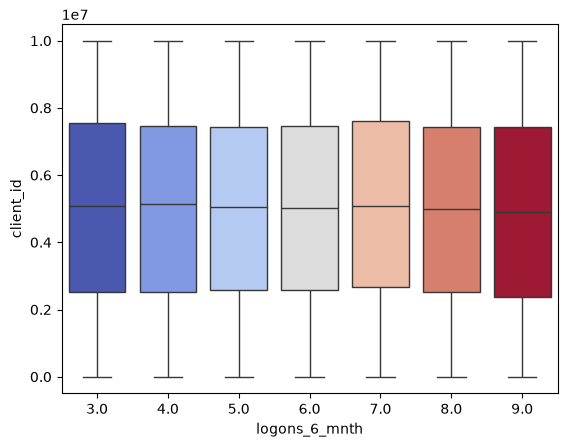

In [47]:
sns.boxplot(data=clients_in_test_gr, x='logons_6_mnth', y='client_id', palette="coolwarm", hue='logons_6_mnth', legend=False);

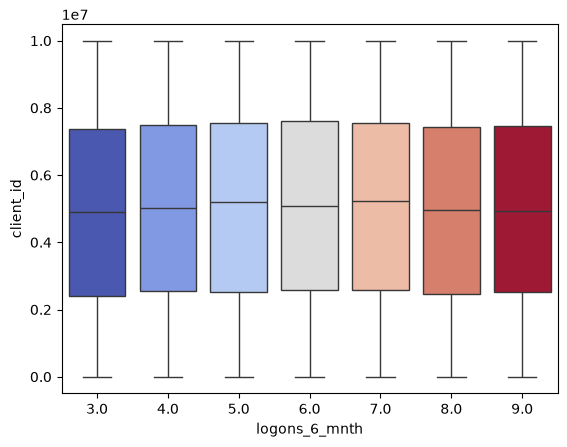

In [48]:
sns.boxplot(data=clients_in_control_gr, x='logons_6_mnth', y='client_id', palette="coolwarm", hue='logons_6_mnth', legend=False);

**Conclusion**
We have perfectly distributed groups of clients by "Logon" metric

In [50]:
merged_df["combo_id"] = (merged_df["client_id"].astype(str)+"-"+merged_df["visitor_id"].astype(str)+"-"+merged_df["visit_id"].astype(str))
merged_df["process_step"].value_counts()

process_step
start      243945
step_1     163193
step_2     133062
step_3     112242
confirm    102963
Name: count, dtype: int64

In [51]:
merged_df["process_step"] = merged_df["process_step"].map({'start': 0, 'step_1': 1, 'step_2': 2, 'step_3': 3, 'confirm': 4})


In [52]:
# t_activity - 'df_final_web_data' without session info
t_activity = merged_df[merged_df["client_id"].isin(clients_in_test_gr["client_id"])]

# grouped_t - getting sessions from 'date_time' column into 
grouped_t = t_activity.groupby(['visit_id'], as_index=False).agg(d_max=('date_time', 'max'), d_min=('date_time', 'min'))
grouped_t['session_sec'] = (grouped_t['d_max'] - grouped_t['d_min']).dt.total_seconds()

# joining dataset t_activity + grouped_t -> we're getting 'session_minutes', 'd_max', 'd_min' instead 'date_time' column
t_activity_final = t_activity.set_index("visit_id").join(grouped_t.set_index("visit_id"), how='inner')
t_activity_final = t_activity_final.reset_index()
t_activity_final

,visit_id,client_id,visitor_id,process_step,date_time,combo_id,d_max,d_min,session_sec
0,637149525_38041617439_716659,555,402506806_56087378777,4,2017-04-15 13:00:34,555-402506806_56087378777-637149525_3804161743...,2017-04-15 13:00:34,2017-04-15 12:57:56,158.0
1,637149525_38041617439_716659,555,402506806_56087378777,0,2017-04-15 12:57:56,555-402506806_56087378777-637149525_3804161743...,2017-04-15 13:00:34,2017-04-15 12:57:56,158.0
2,637149525_38041617439_716659,555,402506806_56087378777,1,2017-04-15 12:58:03,555-402506806_56087378777-637149525_3804161743...,2017-04-15 13:00:34,2017-04-15 12:57:56,158.0
3,637149525_38041617439_716659,555,402506806_56087378777,2,2017-04-15 12:58:35,555-402506806_56087378777-637149525_3804161743...,2017-04-15 13:00:34,2017-04-15 12:57:56,158.0
4,637149525_38041617439_716659,555,402506806_56087378777,3,2017-04-15 13:00:14,555-402506806_56087378777-637149525_3804161743...,2017-04-15 13:00:34,2017-04-15 12:57:56,158.0
...,...,...,...,...,...,...,...,...,...
177842,493310979_9209676464_421146,9999729,843385170_36953471821,0,2017-04-20 14:28:57,9999729-843385170_36953471821-493310979_920967...,2017-04-20 14:28:57,2017-04-20 14:21:27,450.0
177843,493310979_9209676464_421146,9999729,843385170_36953471821,1,2017-04-20 14:22:49,9999729-843385170_36953471821-493310979_920967...,2017-04-20 14:28:57,2017-04-20 14:21:27,450.0
177844,493310979_9209676464_421146,9999729,843385170_36953471821,2,2017-04-20 14:27:36,9999729-843385170_36953471821-493310979_920967...,2017-04-20 14:28:57,2017-04-20 14:21:27,450.0
177845,472154369_16714624241_585315,9999832,145538019_54444341400,0,2017-05-16 16:46:03,9999832-145538019_54444341400-472154369_167146...,2017-05-16 16:46:11,2017-05-16 16:46:03,8.0


In [53]:
t_activity

,client_id,visitor_id,visit_id,process_step,date_time,combo_id
12,555,402506806_56087378777,637149525_38041617439_716659,4,2017-04-15 13:00:34,555-402506806_56087378777-637149525_3804161743...
13,555,402506806_56087378777,637149525_38041617439_716659,0,2017-04-15 12:57:56,555-402506806_56087378777-637149525_3804161743...
14,555,402506806_56087378777,637149525_38041617439_716659,1,2017-04-15 12:58:03,555-402506806_56087378777-637149525_3804161743...
15,555,402506806_56087378777,637149525_38041617439_716659,2,2017-04-15 12:58:35,555-402506806_56087378777-637149525_3804161743...
16,555,402506806_56087378777,637149525_38041617439_716659,3,2017-04-15 13:00:14,555-402506806_56087378777-637149525_3804161743...
...,...,...,...,...,...,...
755376,9999729,843385170_36953471821,493310979_9209676464_421146,0,2017-04-20 14:28:57,9999729-843385170_36953471821-493310979_920967...
755377,9999729,843385170_36953471821,493310979_9209676464_421146,1,2017-04-20 14:22:49,9999729-843385170_36953471821-493310979_920967...
755378,9999729,843385170_36953471821,493310979_9209676464_421146,2,2017-04-20 14:27:36,9999729-843385170_36953471821-493310979_920967...
755391,9999832,145538019_54444341400,472154369_16714624241_585315,0,2017-05-16 16:46:03,9999832-145538019_54444341400-472154369_167146...


In [54]:

t_activity_final.describe()

,client_id,process_step,date_time,d_max,d_min,session_sec
count,1.778470e+05,177847.000000,177847,177847,177847,177847.000000
mean,5.005555e+06,1.581787,2017-04-18 07:31:33.564834,2017-04-18 07:36:06.521346,2017-04-18 07:27:47.250293,499.271053
min,5.550000e+02,0.000000,2017-03-15 00:43:23,2017-03-15 00:44:38,2017-03-15 00:43:23,0.000000
25%,2.506130e+06,0.000000,2017-04-03 17:29:01.500000,2017-04-03 17:33:17.500000,2017-04-03 17:26:19,139.000000
50%,5.061459e+06,1.000000,2017-04-12 11:40:13,2017-04-12 11:45:21,2017-04-12 11:35:58,267.000000
75%,7.474303e+06,3.000000,2017-04-24 13:09:25.500000,2017-04-24 13:12:26,2017-04-24 13:02:52,540.000000
max,9.999832e+06,4.000000,2017-06-20 23:21:23,2017-06-20 23:21:23,2017-06-20 23:14:06,31624.000000
std,2.879374e+06,1.427369,NaN,NaN,NaN,831.534310


In [58]:
joined_data_test = t_activity_final.set_index("client_id").join(clients_in_test_gr.set_index("client_id"), how='inner')
correlation_1 = joined_data_test['session_sec'].corr(joined_data_test['logons_6_mnth'])
correlation_1

np.float64(-0.018779893896396144)

In [60]:
joined_data_test_num = joined_data_test[["session_sec", "clnt_tenure_yr", "clnt_tenure_mnth", "clnt_age", "num_accts", "calls_6_mnth"]]

In [57]:
control_activ = merged_df[merged_df["client_id"].isin(clients_in_control_gr["client_id"])]
control_activ

,client_id,visitor_id,visit_id,process_step,date_time,combo_id
57,1028,42237450_62128060588,557292053_87239438319_391157,0,2017-04-08 18:51:28,1028-42237450_62128060588-557292053_8723943831...
58,1028,42237450_62128060588,557292053_87239438319_391157,1,2017-04-08 18:52:17,1028-42237450_62128060588-557292053_8723943831...
59,1028,42237450_62128060588,557292053_87239438319_391157,1,2017-04-08 18:53:20,1028-42237450_62128060588-557292053_8723943831...
60,1028,42237450_62128060588,557292053_87239438319_391157,1,2017-04-08 18:59:55,1028-42237450_62128060588-557292053_8723943831...
61,1028,42237450_62128060588,557292053_87239438319_391157,1,2017-04-08 19:00:15,1028-42237450_62128060588-557292053_8723943831...
...,...,...,...,...,...,...
755271,9998346,292425655_16607136645,189177304_69869411700_783154,3,2017-03-29 15:28:00,9998346-292425655_16607136645-189177304_698694...
755272,9998346,292425655_16607136645,189177304_69869411700_783154,3,2017-03-29 15:30:25,9998346-292425655_16607136645-189177304_698694...
755273,9998346,292425655_16607136645,189177304_69869411700_783154,3,2017-03-29 15:37:28,9998346-292425655_16607136645-189177304_698694...
755274,9998346,292425655_16607136645,189177304_69869411700_783154,3,2017-03-29 15:37:28,9998346-292425655_16607136645-189177304_698694...


In [61]:
control_activ_sorted = control_activ.sort_values(by=['visit_id', 'date_time'])
control_activ_sorted

,client_id,visitor_id,visit_id,process_step,date_time,combo_id
8183,105007,676020267_36602664238,100030127_47967100085_936361,0,2017-03-22 11:07:49,105007-676020267_36602664238-100030127_4796710...
422818,5623007,700426174_33289797318,100037962_47432393712_705583,0,2017-04-14 16:41:51,5623007-700426174_33289797318-100037962_474323...
422819,5623007,700426174_33289797318,100037962_47432393712_705583,0,2017-04-14 16:43:16,5623007-700426174_33289797318-100037962_474323...
422821,5623007,700426174_33289797318,100037962_47432393712_705583,1,2017-04-14 16:43:55,5623007-700426174_33289797318-100037962_474323...
422820,5623007,700426174_33289797318,100037962_47432393712_705583,0,2017-04-14 16:44:03,5623007-700426174_33289797318-100037962_474323...
...,...,...,...,...,...,...
305004,4064969,110735946_42614968419,999985675_64610694964_443659,0,2017-04-20 09:45:18,4064969-110735946_42614968419-999985675_646106...
305005,4064969,110735946_42614968419,999985675_64610694964_443659,1,2017-04-20 09:46:26,4064969-110735946_42614968419-999985675_646106...
305006,4064969,110735946_42614968419,999985675_64610694964_443659,2,2017-04-20 09:47:04,4064969-110735946_42614968419-999985675_646106...
305007,4064969,110735946_42614968419,999985675_64610694964_443659,3,2017-04-20 09:48:45,4064969-110735946_42614968419-999985675_646106...


In [70]:
gr_s_activities = control_activ_sorted.groupby(['client_id','visit_id'])['date_time'].agg(['min', 'max'])
gr_s_activities['session_sec'] = (gr_s_activities['max'] - gr_s_activities['min']).dt.total_seconds()
gr_s_activities.describe()

,min,max,session_sec
count,32243,32243,32243.000000
mean,2017-04-21 15:49:41.882858,2017-04-21 15:54:22.393511,280.510653
min,2017-03-15 00:19:28,2017-03-15 00:26:24,0.000000
25%,2017-04-05 11:09:16.500000,2017-04-05 11:12:44,22.000000
50%,2017-04-12 15:43:30,2017-04-12 15:48:11,160.000000
75%,2017-05-05 17:07:07.500000,2017-05-05 17:11:42.500000,341.000000
max,2017-06-20 23:56:17,2017-06-20 23:57:06,41965.000000
std,NaN,NaN,529.560467


In [71]:
gr_s_activities = gr_s_activities.reset_index()

In [72]:
gr_s_activities

,client_id,visit_id,min,max,session_sec
0,1028,557292053_87239438319_391157,2017-04-08 18:51:28,2017-04-08 19:00:26,538.0
1,1104,543158812_46395476577_767725,2017-06-12 07:49:18,2017-06-12 07:49:18,0.0
2,1104,643221571_99977972121_69283,2017-06-20 22:31:33,2017-06-20 22:31:33,0.0
3,1186,507052512_11309370126_442139,2017-04-08 15:59:16,2017-04-08 15:59:16,0.0
4,1186,795373564_99931517312_810896,2017-04-08 18:05:02,2017-04-08 18:05:24,22.0
...,...,...,...,...,...
32238,9997470,655572400_94971272893_411965,2017-04-07 16:11:03,2017-04-07 16:11:03,0.0
32239,9997470,761490147_96352537762_21814,2017-05-09 15:55:48,2017-05-09 16:39:34,2626.0
32240,9997470,904791598_9725982898_416914,2017-04-20 20:04:38,2017-04-20 20:04:38,0.0
32241,9998346,189177304_69869411700_783154,2017-03-29 15:25:00,2017-03-29 15:37:28,748.0


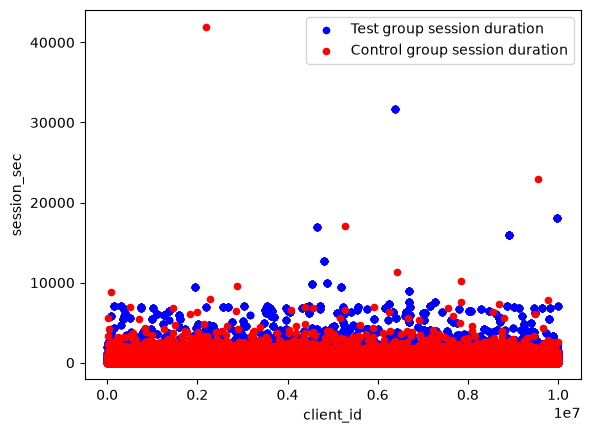

In [73]:
fig, ax = plt.subplots()
t_activity_final.plot.scatter(x='client_id', y='session_sec', color='blue', label='Test group session duration', ax=ax)
gr_s_activities.plot.scatter(x='client_id', y='session_sec', color='red', label='Control group session duration', ax=ax)
plt.show()

In [75]:
joined_data_control = gr_s_activities.set_index("client_id").join(clients_in_control_gr.set_index("client_id"), how='inner')
correlation_2 = joined_data_control['session_sec'].corr(joined_data_control['logons_6_mnth'])
correlation_2

np.float64(-0.04179559519435597)

In [77]:
joined_data_control_num = joined_data_control[["session_sec", "clnt_tenure_yr", "clnt_tenure_mnth", "clnt_age", "num_accts", "calls_6_mnth", "logons_6_mnth"]]

In [79]:
corr_control = joined_data_control_num.corrwith(joined_data_control['session_sec'], method='pearson')
corr_control

session_sec         1.000000
clnt_tenure_yr      0.008811
clnt_tenure_mnth    0.008830
clnt_age            0.067716
num_accts          -0.030764
calls_6_mnth       -0.043413
logons_6_mnth      -0.041796
dtype: float64

In [80]:
corr_test = joined_data_test_num.corrwith(joined_data_test['session_sec'], method='pearson')
corr_test

session_sec         1.000000
clnt_tenure_yr      0.018710
clnt_tenure_mnth    0.019590
clnt_age            0.102497
num_accts          -0.013146
calls_6_mnth       -0.020581
dtype: float64

In [81]:
joined_data_control = joined_data_control.reset_index()
joined_data_test = joined_data_test.reset_index()

In [83]:
test_dataset = joined_data_test[["session_sec", "clnt_tenure_yr", "clnt_tenure_mnth", "num_accts", "logons_6_mnth"]]
control_dataset = joined_data_control[["session_sec", "clnt_tenure_yr", "clnt_tenure_mnth", "num_accts", "logons_6_mnth"]]

In [84]:
test_dataset.shape

(177847, 5)

In [85]:
test_dataset.isna().sum()

session_sec          0
clnt_tenure_yr      60
clnt_tenure_mnth    60
num_accts           60
logons_6_mnth       60
dtype: int64

In [86]:
test_dataset = test_dataset.dropna(subset=["clnt_tenure_yr", "clnt_tenure_mnth", "num_accts", "logons_6_mnth"])

In [87]:
test_dataset.isna().sum()

session_sec         0
clnt_tenure_yr      0
clnt_tenure_mnth    0
num_accts           0
logons_6_mnth       0
dtype: int64

In [88]:
control_dataset.shape

(32243, 5)

In [89]:
control_dataset.isna().sum()

session_sec         0
clnt_tenure_yr      6
clnt_tenure_mnth    6
num_accts           6
logons_6_mnth       6
dtype: int64

In [90]:
control_dataset = control_dataset.dropna(subset=["clnt_tenure_yr", "clnt_tenure_mnth", "num_accts", "logons_6_mnth"])

In [91]:
control_dataset.isna().sum()

session_sec         0
clnt_tenure_yr      0
clnt_tenure_mnth    0
num_accts           0
logons_6_mnth       0
dtype: int64

In [92]:
# H0 - datasets are equal
# H1 - datasets have some diferencies 
alpha = 0.05
_, p_value = st.ttest_ind(test_dataset, control_dataset, equal_var=False)

In [93]:
# columns used for t-test: "session_minutes", "clnt_tenure_yr", "clnt_tenure_mnth", "num_accts", "logons_6_mnth"
for p in p_value:
    if p > alpha:
        print("We are not able to reject the null hypothesis. p_value is", p)
    else:
        print("We reject the null hypothesis. p_value is", p)

We reject the null hypothesis. p_value is 0.0
We reject the null hypothesis. p_value is 0.00012139647881077047
We reject the null hypothesis. p_value is 0.00017106606116760914
We reject the null hypothesis. p_value is 1.0324957016099435e-15
We reject the null hypothesis. p_value is 1.368707064534413e-21


**Conclusions**
- After AB-test we have some diffirences for all metricks: "session_minutes", "clnt_tenure_yr", "clnt_tenure_mnth", "num_accts", "logons_6_mnth"

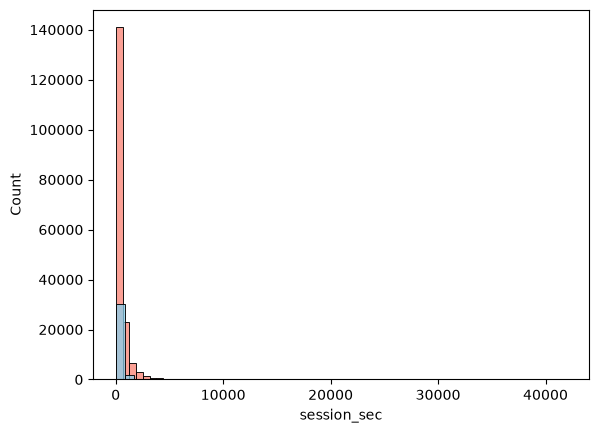

In [95]:
fig, axes = plt.subplots()
sns.histplot(test_dataset['session_sec'], bins=50, color="salmon", ax=axes);
sns.histplot(control_dataset['session_sec'], bins=50, color="skyblue", ax=axes);
plt.show()

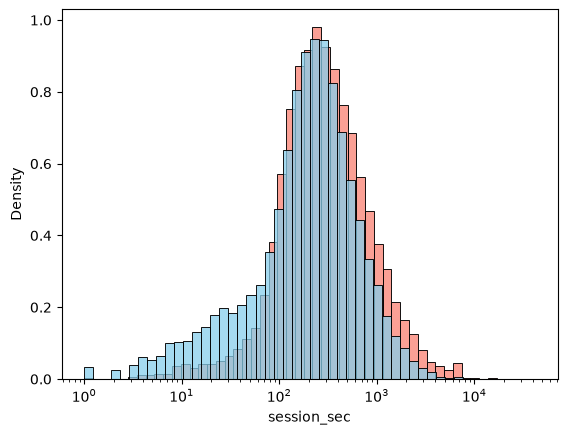

In [96]:
fig, axes = plt.subplots()
sns.histplot(test_dataset['session_sec'], stat="density", bins=50, color="salmon", ax=axes, log_scale=True);
sns.histplot(control_dataset['session_sec'],stat="density", bins=50, color="skyblue", ax=axes, log_scale=True);
plt.show()

**Conclusions**
- we have almost the same amount of short sessions (with duration about 0 minutes)
- in test group we decreased amount of long sessions

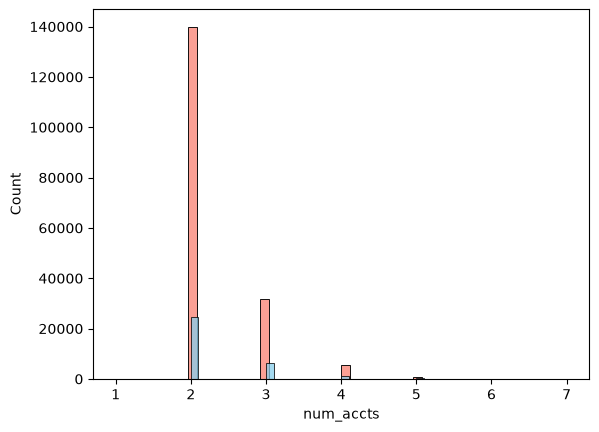

In [97]:
fig, axes = plt.subplots()
sns.histplot(test_dataset['num_accts'], bins=50, color="salmon", ax=axes);
sns.histplot(control_dataset['num_accts'], bins=50, color="skyblue", ax=axes);
plt.show()

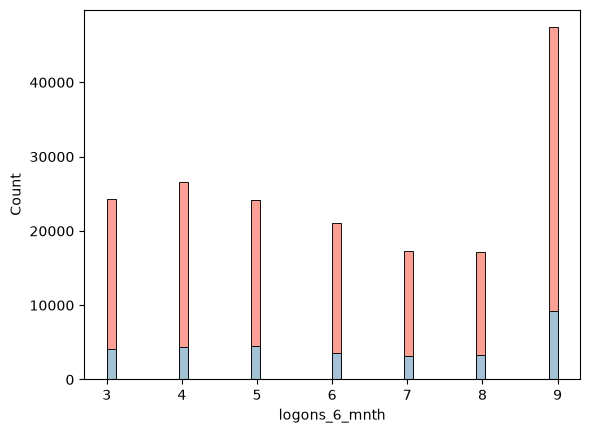

In [98]:
fig, axes = plt.subplots()
sns.histplot(test_dataset['logons_6_mnth'], bins=50, color="salmon", ax=axes);
sns.histplot(control_dataset['logons_6_mnth'], bins=50, color="skyblue", ax=axes);
plt.show()

the number of logins has increased for all group of clients